# Ejemplo Arbol de Decision para Regresion
## 1. Importar librerías

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

## 2. Crear datos de ejemplo (relación no lineal)

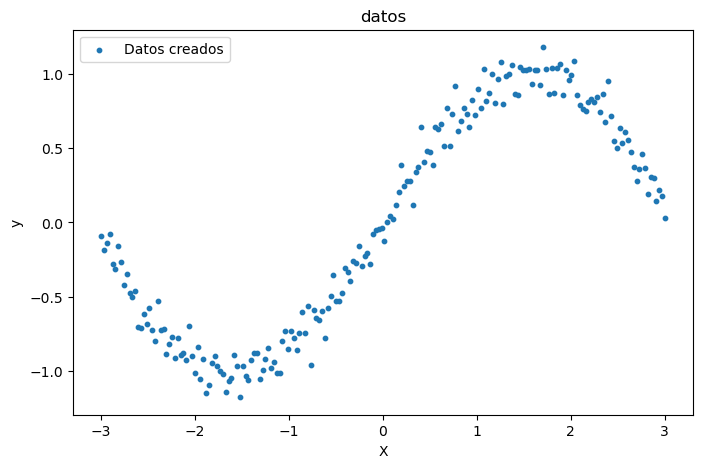

DecisionTreeRegressor(max_depth=5, random_state=42)


In [19]:
np.random.seed(42)

X = np.linspace(-3, 3, 200).reshape(-1, 1)
y = np.sin(X) + np.random.normal(0, 0.1, size=(200, 1))  # función con ruido
modelo = DecisionTreeRegressor(max_depth=5, random_state=42)

# ENTRENAR EL MODELO (faltaba en tu código original)
modelo.fit(X, y)


#Se grafican los datos creados
X_grid = np.linspace(-3, 3, 500).reshape(-1, 1)
y_grid_pred = modelo.predict(X_grid)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, label="Datos creados", s=10)
plt.title("datos")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()


## 3. Dividir datos en entrenamiento y prueba
**train_test_split** es una función de **sklearn.model_selection** que divide (split) tus datos en conjuntos de entrenamiento y prueba (test).\
Recibe tus entradas (X) y etiquetas/targets (Y) y devuelve cuatro objetos: los pares de entrada/target para entrenamiento y prueba.\

**X_train** — las filas de X que irán a entrenamiento\
**X_test** — las filas de X que irán a prueba\
**Y_train** — los targets correspondientes a X_train\
**Y_test** — los targets correspondientes a X_test\
\
**test_size=0.2** (0.2 = 20%) Indica el porcentaje de muestras para el conjunto de prueba.\
Con 100 muestras, **test_size=0.2** hará que X_test tenga ~20 muestras y X_train ~80.\
Otra opcion es indicar **test_size=20**, serían 20 muestras también.\
\
**random_state=42** es la semilla del generador aleatorio para la selección aleatoria de muestras.\
Si se pone un entero fijo (ej. 42), la partición será reproducible: ejecutar el mismo código varias veces da la misma división.\
Si se omite o se indica None, cada ejecución produce una partición diferente.\
\
**Nota:** Por defecto **shuffle=True**, así que se barajan las filas antes de partir; random_state controla ese barajado. Si **shuffle=False**, los datos se parten sin mezclar (útil cuando el orden tiene sentido temporal — por ejemplo, series temporales no se deben mezclar).

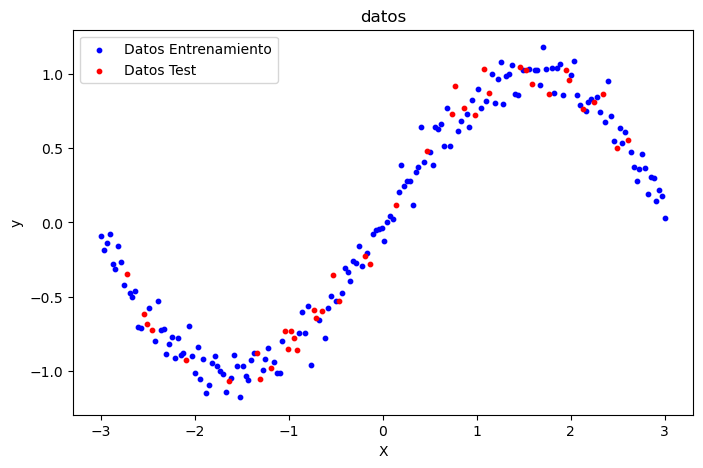

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Se grafican los datos
X_grid = np.linspace(-3, 3, 500).reshape(-1, 1)
y_grid_pred = modelo.predict(X_grid)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, label="Datos Entrenamiento", s=10, color="blue")
plt.scatter(X_test, y_test, label="Datos Test", s=10, color="red")
plt.title("datos")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## 4. Crear y entrenar el árbol de regresión
**DecisionTreeRegressor(...)** instancia un objeto que implementa un árbol de decisión para regresión (algoritmo CART que predice valores continuos).\
Parámetros que aparecen y su efecto inmediato:\
**max_depth=4** Limita la profundidad máxima del árbol (número de divisiones desde la raíz hasta la hoja).\
* **Profundidades pequeñas** → modelo simple, riesgo de underfitting.\
* **Profundidades grandes** → modelo muy flexible, riesgo de overfitting.\
**max_depth=4** es una restricción para evitar que el árbol crezca sin control.\

**random_state=42** Fija la semilla aleatoria usada internamente para decisiones aleatorias (por ejemplo, desempates en cortes, o si usas splitter='random' o max_features que implican selección aleatoria).\
Sirve para **reproducibilidad**, con la misma semilla, obtendrás el mismo árbol al re-entrenarlo.\

In [11]:
modelo = DecisionTreeRegressor(max_depth=4, random_state=42)
modelo.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, random_state=42)

In [12]:
print("Profundidad del árbol:", modelo.get_depth())
print("Número de hojas:", modelo.get_n_leaves())
print("Importancia de variables:", modelo.feature_importances_)

Profundidad del árbol: 4
Número de hojas: 16
Importancia de variables: [1.]


## 5. Realizar predicciones
Utiliza el modelo ya entrenado para generar predicciones sobre los datos de prueba (**X_test**).
Después de aprender la relación entre las variables durante el entrenamiento, el modelo aplica ese conocimiento para estimar los valores de salida correspondientes a los nuevos ejemplos que nunca ha visto. El resultado, **y_pred**, es un conjunto de predicciones que luego se compara con los valores reales para evaluar qué tan bien está funcionando el modelo.

In [13]:
y_pred = modelo.predict(X_test)

## 6. Evaluación del modelo
**mse = mean_squared_error(y_test, y_pred)** El error cuadrático medio mide el error promedio, pero eleva al cuadrado las diferencias.\
mse=(1/n)​∑((yreal​−ypred​)^2) \
**r2 = r2_score(y_test, y_pred)** Mide qué porcentaje de la variación de los datos puede explicar el modelo.\
SST=∑​((yreal​−yprom​)^2)\
SSE=∑​((yreal​−ypred​)^2)\
R²=1- (SSE)/(SST)\
**Interpretación del R²:**\
R²=1.0 → el modelo explica el 100% de la variación (perfecto).\
R²=0 → el modelo no explica nada (predice lo mismo que un promedio).\
R²< 0 → el modelo es peor que adivinar usando el promedio.\
R² ≥ 0.75 → Muy buen modelo (explica la mayor parte de la variación).\
0.50 ≤ R² < 0.75 → Modelo aceptable o bueno, dependiendo del contexto.\
R² < 0.50 → El modelo explica poco; podría mejorarse.

In [15]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R²:", r2)

MSE: 0.018034083647136868
R²: 0.9698694832182279


## 7. Mostrar cómo el árbol aproxima la función

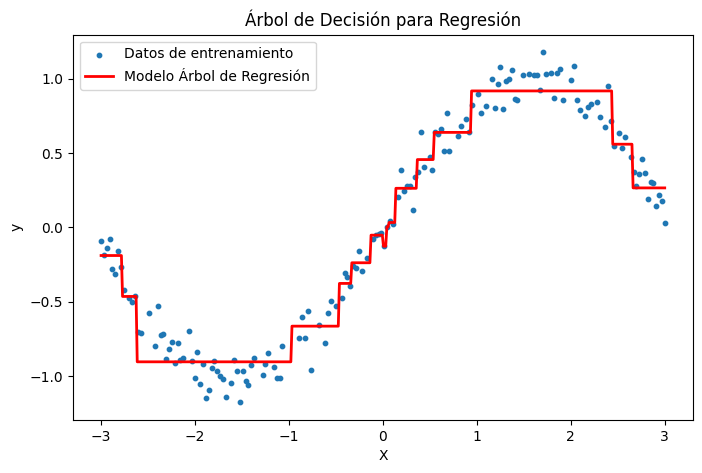

In [57]:
X_grid = np.linspace(-3, 3, 500).reshape(-1, 1)
y_grid_pred = modelo.predict(X_grid)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, label="Datos de entrenamiento", s=10)
plt.plot(X_grid, y_grid_pred, label="Modelo Árbol de Regresión", linewidth=2, color="red")
plt.title("Árbol de Decisión para Regresión")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## 8. Presentacion del arbol de decision

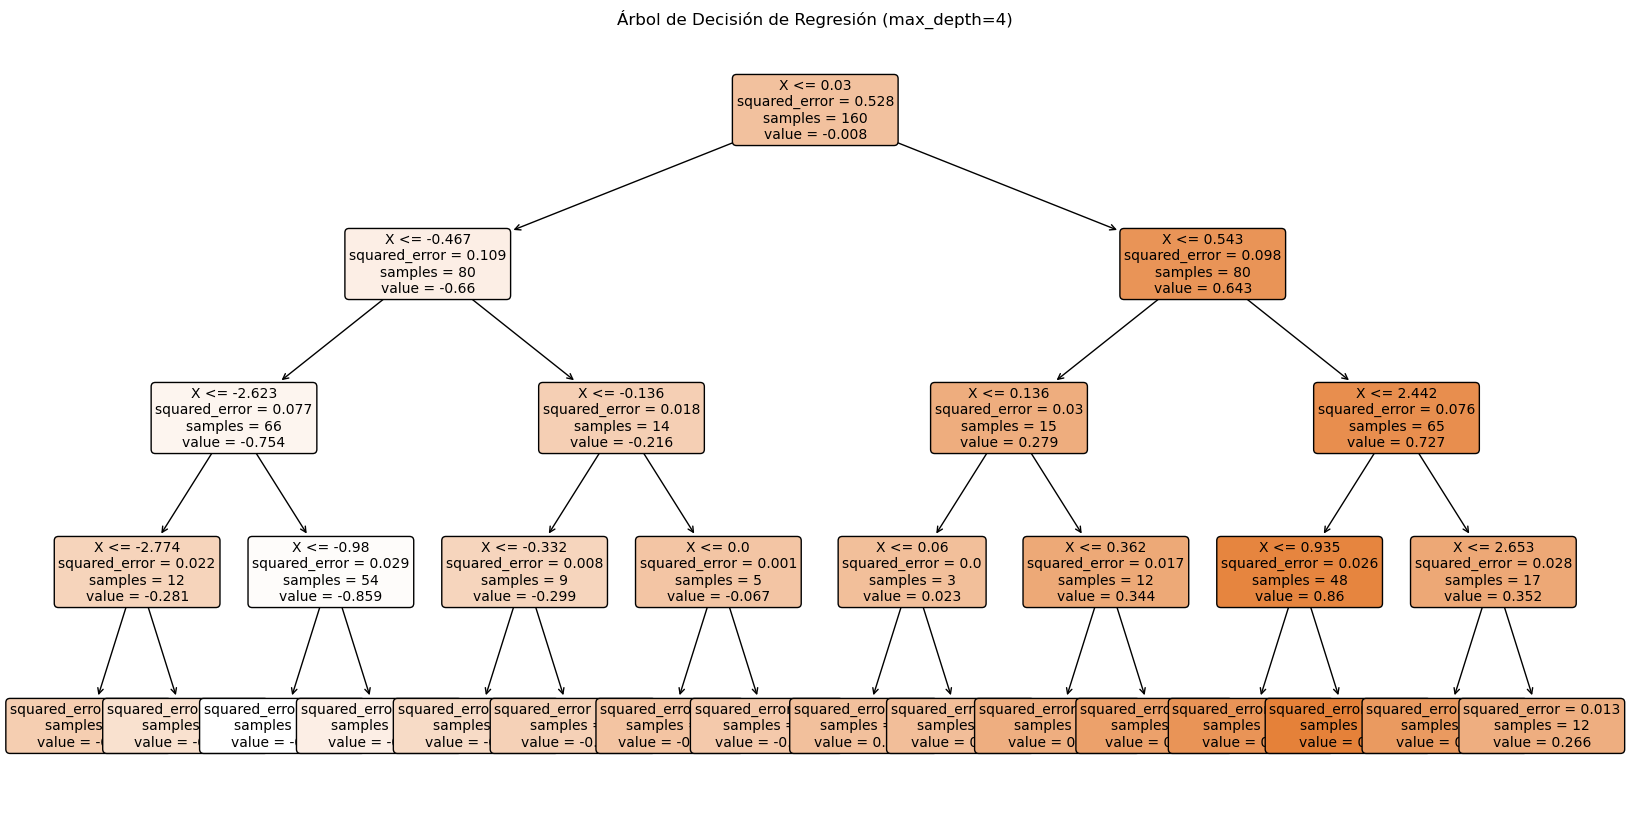

In [16]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    modelo,
    filled=True,
    feature_names=["X"],
    rounded=True,
    fontsize=10
)
plt.title("Árbol de Decisión de Regresión (max_depth=4)")
plt.show()

## Determinar la profundidad Optima
Para encontrar la mejor profundidad del árbol, se entrena el modelo varias veces usando diferentes valores de **max_depth **(por ejemplo, desde 1 hasta 15). Cada versión del modelo se evalúa calculando el coeficiente **R²** sobre los datos de prueba. El **R²** indica qué tan bien el modelo explica la variabilidad real de los datos: valores más altos significan mejor desempeño. Finalmente, se selecciona el **max_depth** que obtiene el mayor **R²**, ya que representa el punto donde el árbol es lo suficientemente complejo para capturar patrones reales sin caer en sobreajuste.


Mejor max_depth encontrado (según test): 5


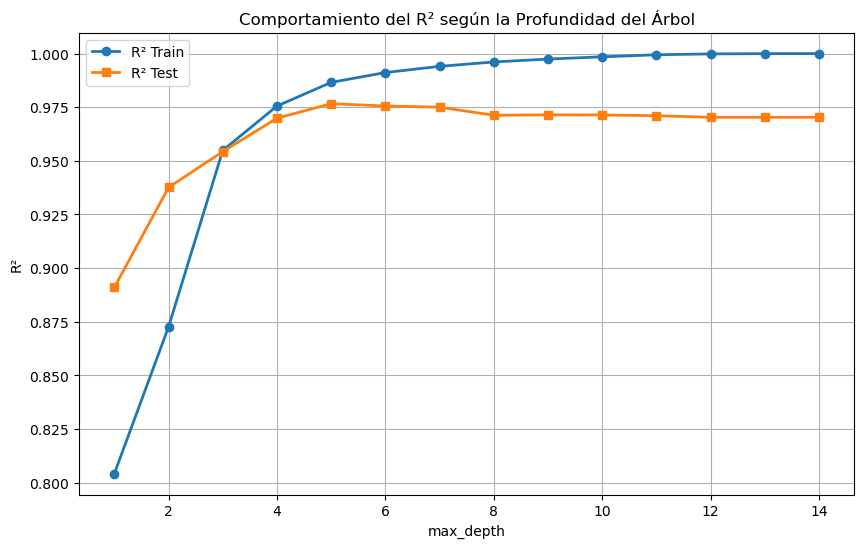

In [20]:
# Rango de profundidades a evaluar
depth_values = range(1, 15)
r2_train_scores = []
r2_test_scores = []

# Evaluar cada profundidad
for d in depth_values:
    modelo_temp = DecisionTreeRegressor(max_depth=d, random_state=42)
    modelo_temp.fit(X_train, y_train)
    
    # Predicciones para train y test
    y_pred_train = modelo_temp.predict(X_train)
    y_pred_test = modelo_temp.predict(X_test)
    
    # Guardar R²
    r2_train_scores.append(r2_score(y_train, y_pred_train))
    r2_test_scores.append(r2_score(y_test, y_pred_test))

# Mejor profundidad según TEST
best_depth = depth_values[np.argmax(r2_test_scores)]
print("\nMejor max_depth encontrado (según test):", best_depth)

# -----------------------------------------------------------
# Gráfica comparativa: R² train vs R² test
# -----------------------------------------------------------

plt.figure(figsize=(10, 6))
plt.plot(depth_values, r2_train_scores, marker='o', label="R² Train", linewidth=2)
plt.plot(depth_values, r2_test_scores, marker='s', label="R² Test", linewidth=2)

plt.title("Comportamiento del R² según la Profundidad del Árbol")
plt.xlabel("max_depth")
plt.ylabel("R²")
plt.legend()
plt.grid(True)
plt.show()